# HATR cross-framework — Performance computazionale

Confronto del costo computazionale di HATR in River (Python) e CapyMOA (JVM via JNI) su 4 dataset: tempo di training, inferenza, throughput e crescita della dimensione modello.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    SIZEOF_JAR = os.path.expanduser(
        "~/.m2/repository/com/github/fracpete/sizeofag/1.1.0/sizeofag-1.1.0.jar")
    if os.path.exists(SIZEOF_JAR):
        os.environ["CAPYMOA_JVM_ARGS"] = (
            f"-Xmx8g -Xss10M -javaagent:{SIZEOF_JAR} "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "-XX:ErrorFile=/dev/null"
        )
    else:
        os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression
import psutil
from pympler import asizeof

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [8]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

datasets = {}
datasets["Synthetic"] = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]      = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]     = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]     = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<10} n={len(X):>6}  feat={X.shape[1]:>2}  y∈[{y.min():.2f}, {y.max():.2f}]")

Synthetic  n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike       n= 17000  feat=12  y∈[1.00, 977.00]
Fried      n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper      n= 17000  feat=10  y∈[93.98, 677.42]


## Parametri

In [3]:
BASE = dict(grace_period=50, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=500, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.0001, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True

## Esecuzione

In [9]:
SAMPLE_EVERY = 500
PERF_CONFIG  = "default (adaptive, bootstrap)"
cfg = CONFIGS[PERF_CONFIG]

# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', cfg, BASE, schema=_w_schema, scale=SCALE)

rows = []
for ds_name, (X, y, schema) in datasets.items():
    n = len(X)
    _, r_model, rt_p, rt_t, _ = utils.prequential_eval(X, y, 'river', cfg, BASE, time_algo=True)
    _, c_learner, ct_p, ct_t, _ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, time_algo=True)
    r_mb = utils.river_model_mb(r_model)
    c_mb = utils.capy_model_mb(c_learner)
    rows.append(dict(dataset=ds_name, framework="River", n=n,
                     train_s=rt_t, predict_s=rt_p, total_s=rt_t + rt_p,
                     inst_per_s=n / (rt_t + rt_p), model_MB=r_mb))
    rows.append(dict(dataset=ds_name, framework="CapyMOA", n=n,
                     train_s=ct_t, predict_s=ct_p, total_s=ct_t + ct_p,
                     inst_per_s=n / (ct_t + ct_p), model_MB=c_mb))
    print(f"  {ds_name:<10} River {rt_t+rt_p:6.2f}s {r_mb:.3f} MB  |  CapyMOA {ct_t+ct_p:6.2f}s {c_mb:.4f} MB")

perf = pd.DataFrame(rows)
speedup = (perf[perf.framework == "CapyMOA"].set_index("dataset")["inst_per_s"] /
           perf[perf.framework == "River"].set_index("dataset")["inst_per_s"])
perf["speedup_vs_river"] = perf["dataset"].map(speedup)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
perf

  Synthetic  River   1.48s 3.485 MB  |  CapyMOA   0.21s 0.4493 MB
  Bike       River   1.54s 1.457 MB  |  CapyMOA   0.39s 0.3459 MB
  Fried      River   2.67s 3.866 MB  |  CapyMOA   0.38s 0.2726 MB
  Hyper      River   2.98s 0.873 MB  |  CapyMOA   0.31s 0.1711 MB


,dataset,framework,n,train_s,predict_s,total_s,inst_per_s,model_MB,speedup_vs_river
0,Synthetic,River,17000,1.3961,0.0792,1.4753,11523.2056,3.4848,7.0755
1,Synthetic,CapyMOA,17000,0.1492,0.0593,0.2085,81532.0051,0.4493,7.0755
2,Bike,River,17000,1.4705,0.0659,1.5363,11065.2921,1.4575,3.9309
3,Bike,CapyMOA,17000,0.3311,0.0598,0.3908,43496.6744,0.3459,3.9309
4,Fried,River,17000,2.5894,0.0799,2.6692,6368.8684,3.8660,7.0389
5,Fried,CapyMOA,17000,0.3195,0.0597,0.3792,44829.8203,0.2726,7.0389
6,Hyper,River,17000,2.9046,0.0738,2.9783,5707.9222,0.8731,9.5214
7,Hyper,CapyMOA,17000,0.2534,0.0594,0.3128,54347.3886,0.1711,9.5214


## Grafici

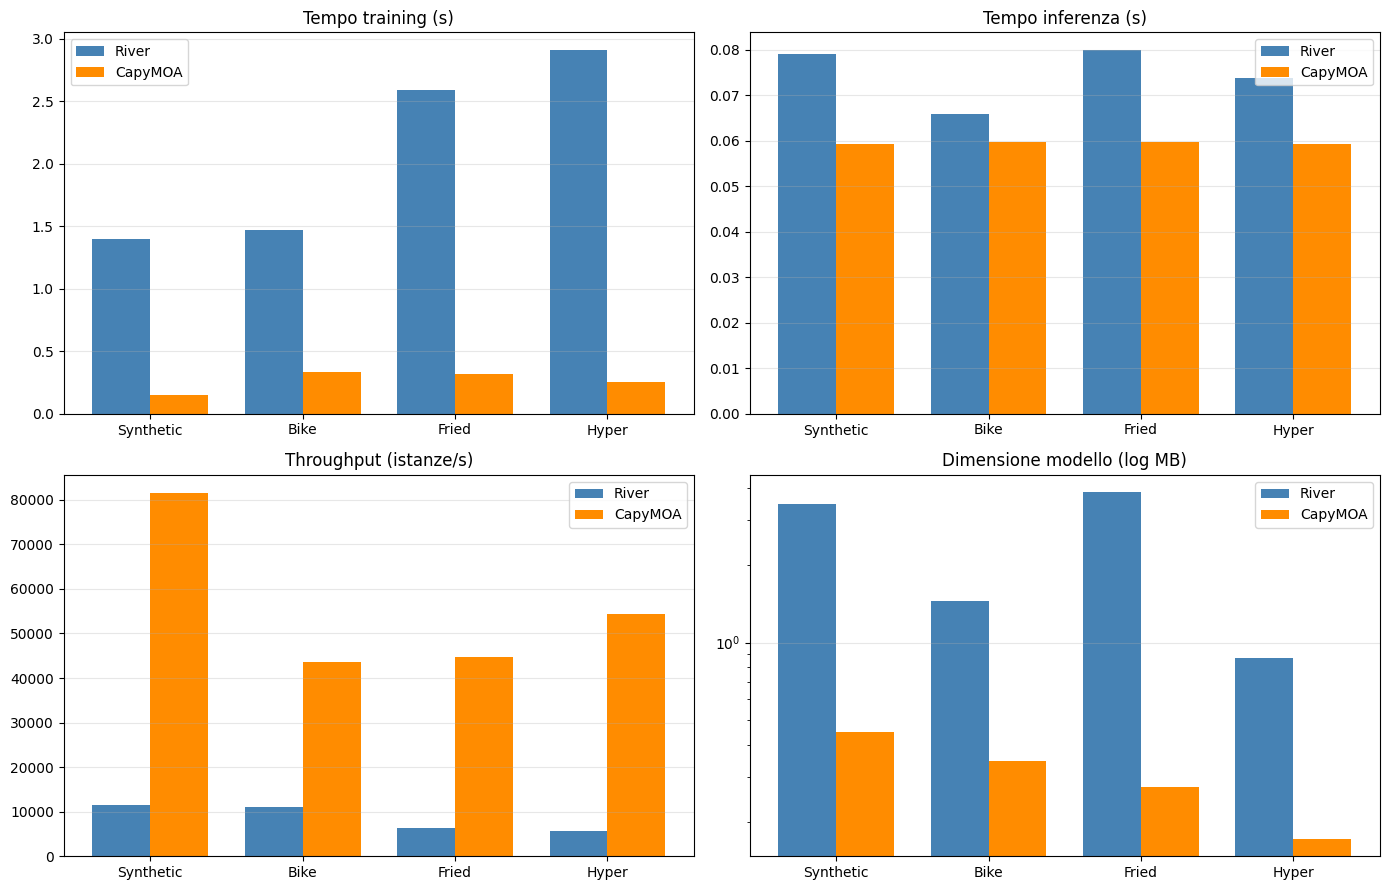

  dataset framework  train_s  predict_s  inst_per_s  model_MB  speedup_vs_river
Synthetic     River   1.3961     0.0792  11523.2056    3.4848            7.0755
Synthetic   CapyMOA   0.1492     0.0593  81532.0051    0.4493            7.0755
     Bike     River   1.4705     0.0659  11065.2921    1.4575            3.9309
     Bike   CapyMOA   0.3311     0.0598  43496.6744    0.3459            3.9309
    Fried     River   2.5894     0.0799   6368.8684    3.8660            7.0389
    Fried   CapyMOA   0.3195     0.0597  44829.8203    0.2726            7.0389
    Hyper     River   2.9046     0.0738   5707.9222    0.8731            9.5214
    Hyper   CapyMOA   0.2534     0.0594  54347.3886    0.1711            9.5214


In [10]:
ds_order = list(datasets.keys())
def vals(metric, fw):
    return [perf[(perf.dataset == d) & (perf.framework == fw)][metric].values[0] for d in ds_order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ("train_s",    "Tempo training (s)",         False),
    ("predict_s",  "Tempo inferenza (s)",         False),
    ("inst_per_s", "Throughput (istanze/s)",      False),
    ("model_MB",   "Dimensione modello (log MB)", True),
]
for ax, (metric, title, log_scale) in zip(axes.ravel(), panels):
    rv, cm = vals(metric, "River"), vals(metric, "CapyMOA")
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River",   color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(perf[["dataset", "framework", "train_s", "predict_s", "inst_per_s",
            "model_MB", "speedup_vs_river"]].to_string(index=False))

## Crescita dimensione modello

Synthetic: River 4.084 MB | CapyMOA 0.7634 MB
Bike: River 0.837 MB | CapyMOA 0.1747 MB
Fried: River 6.931 MB | CapyMOA 1.0828 MB
Hyper: River 8.501 MB | CapyMOA 1.3004 MB


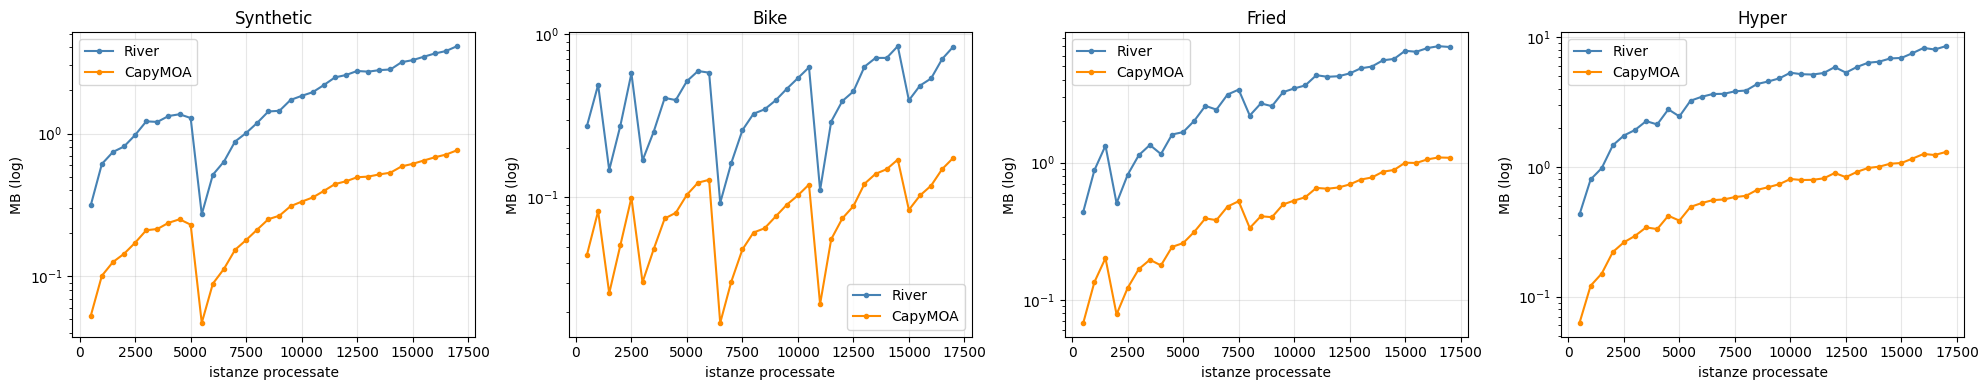

In [6]:
cfg = CONFIGS["deterministic (mean, no-bootstrap)"]
traces = {}
for ds_name, (X, y, schema) in datasets.items():
    _, _, _, _, tr_r = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE, sample_every=SAMPLE_EVERY)
    _, _, _, _, tr_c = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE, sample_every=SAMPLE_EVERY)
    traces[ds_name] = {"River": tr_r, "CapyMOA": tr_c}
    print(f"{ds_name}: River {tr_r[-1]['model_MB']:.3f} MB | CapyMOA {tr_c[-1]['model_MB']:.4f} MB")

colors  = {"River": "steelblue", "CapyMOA": "darkorange"}
ds_list = list(datasets.keys())

fig, axes = plt.subplots(1, len(ds_list), figsize=(5 * len(ds_list), 4))
for ax, ds_name in zip(axes, ds_list):
    for fw in ("River", "CapyMOA"):
        t  = traces[ds_name][fw]
        ns = [p["n"]        for p in t]
        vs = [p["model_MB"] for p in t]
        ax.plot(ns, vs, label=fw, color=colors[fw], marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set_title(ds_name)
    ax.set_xlabel("istanze processate")
    ax.set_ylabel("MB (log)")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()